In [2]:
#2
def load_data(file_name: str) :
    """"
        Helper functions that extracts the data from the input files.
        The format based on which it extracts can be seen at 'knapsack-20.txt'
        The first line holds the nr of total objects n, then n lines represeting 
        the index, value and weight of the values, then the max_weight is on the last line. 
    Args:
        file_name (str): Input file for extracting data

    Returns:
        int : The total number of objects 
        list[tuple[int, int]]: The results consists of the n tuples(represnting (value, weight) pairs)
        int : The maximum value for the total weight
    """
    weights_and_values = []
    with open(file_name) as f:
        total = int(f.readline())
        for _ in range(total) :
            values = f.readline().split()
            # print(values)
            n2 = int(values[1])
            n3 = int(values[2])
            weights_and_values.append((n2, n3))
        
        max_value = int(f.readline())
    
    return total, weights_and_values, max_value

In [3]:
def compute_value_for_solution(solution :tuple, max_value_weight, weights_values:list[tuple]) :
    """For each solution generated it computes the total value accumulated and
    the weight it reaches , if the weight is valid it return the maximum one, otherwise -1.

    Args:
        solution (tuple): The tuple of size n representing the made out of 0s and 1s, representing
        whether the values are added or not.
        max_value_value (int): The maximum weight given as input
        weights_values (list[tuple]) : The input data for all the objects (value, weight) pairs
        
    Returns:
    int : Returns the total value if the weight is lower that the max_value_weight,
            otherwise returns -1
    """
    sum_values = 0
    sum_weights = 0
    
    for i in range(len(solution)) :
        sum_values+=solution[i]*weights_values[i][0]
        sum_weights+=solution[i]*weights_values[i][1]
        
    if sum_weights <= max_value_weight :
        return sum_values
    return -1

In [19]:
import random
from collections import deque

def tabu_for_knapsack(filename: str, iterations: int, tabu_tenure: int = 5):
    size, weights_values, max_weight = load_data(filename)

    c = [random.randint(0, 1) for _ in range(size)]

    best = c.copy()
    best_fitness = compute_value_for_solution(best, max_weight, weights_values)

    M = deque(maxlen=tabu_tenure)

    for _ in range(iterations):
        x, x_fitness, x_index = None, -float('inf'), -1
        for i in range(size):
            neighbor = c.copy()
            neighbor[i] = 1 - neighbor[i]
            neighbor_fitness = compute_value_for_solution(neighbor, max_weight, weights_values)

            if i not in M or neighbor_fitness > best_fitness:
                if neighbor_fitness > x_fitness:
                    x, x_fitness, x_index = neighbor.copy(), neighbor_fitness, i

        if x is None:
            continue
        
        M.append(x_index)
        c = x

        if x_fitness > best_fitness:
            best = x.copy()
            best_fitness = x_fitness

    return best_fitness


print(tabu_for_knapsack('../Lab1Assigment1/knapsack-20.txt', 100))
print(tabu_for_knapsack('../Lab1Assigment1/knapsack-200.txt', 100))

726
-1


In [20]:
import math
import random

def load_tsp(filename: str) -> list:
    coords = []
    with open(filename) as f:
        for line in f:
            if line.strip() == 'NODE_COORD_SECTION':
                break
        for line in f:
            if line.strip() == 'EOF':
                break
            parts = line.split()
            x, y = float(parts[1]), float(parts[2])
            coords.append((x, y))
    return coords

In [21]:
def euclidean_distance(a: tuple, b: tuple) -> float:
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def tour_length(tour: list, coords: list) -> float:
    total = 0
    for i in range(len(tour)):
        total += euclidean_distance(coords[tour[i]], coords[tour[(i + 1) % len(tour)]])
    return total

In [22]:
def greedy_tsp(filename: str) -> tuple:
    coords = load_tsp(filename)
    n = len(coords)
    start = 0

    tour = [start]
    available = set(range(n))
    available.remove(start)
    current = start

    while available:
        nearest = None
        nearest_dist = float('inf')

        for node in available:
            dist = euclidean_distance(coords[current], coords[node])
            if dist < nearest_dist:
                nearest_dist = dist
                nearest = node        
        tour.append(nearest)
        available.remove(nearest)
        current = nearest

    length = tour_length(tour, coords)
    return tour, length


tour, length = greedy_tsp('../Lab3Assigment3/berlin52.tsp')
print(f"tour: {[node + 1 for node in tour]}")  
print(f"distance: {length}")

tour: [1, 22, 49, 32, 36, 35, 34, 39, 40, 38, 37, 48, 24, 5, 15, 6, 4, 25, 46, 44, 16, 50, 20, 23, 31, 18, 3, 19, 45, 41, 8, 10, 9, 43, 33, 51, 12, 28, 27, 26, 47, 13, 14, 52, 11, 29, 30, 21, 17, 42, 7, 2]
distance: 8980.918279329191


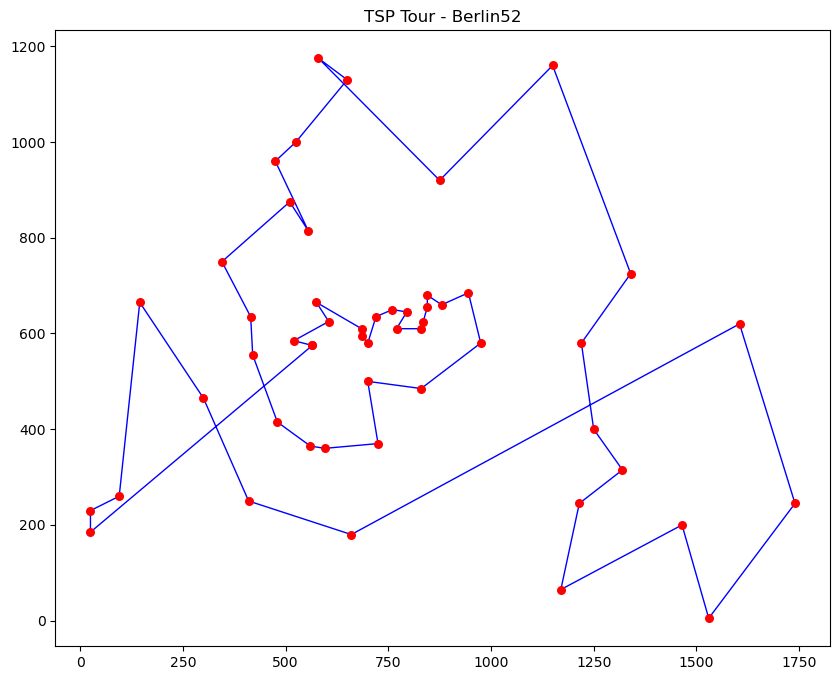

In [13]:
import matplotlib.pyplot as plt

coords = load_tsp('../Lab3Assigment3/berlin52.tsp')
tour, distance = greedy_tsp('../Lab3Assigment3/berlin52.tsp')

x = [coords[tour[i]][0] for i in range(len(tour))] + [coords[tour[0]][0]]
y = [coords[tour[i]][1] for i in range(len(tour))] + [coords[tour[0]][1]]

plt.figure(figsize=(10, 8))
plt.plot(x, y, 'b-', linewidth=1)        
plt.scatter(x, y, c='red', s=30, zorder=5)  
plt.title("TSP Tour - Berlin52")
plt.show()